#  Assumptions of Linear Regression

In statistical modeling, **Linear Regression** relies on the framework of **Ordinary Least Squares (OLS)** estimation. For OLS estimators to be the **Best Linear Unbiased Estimator (BLUE)**—a foundational rule known as the **Gauss-Markov Theorem**—the data-generating process must strictly adhere to specific structural assumptions. 

The baseline multiple linear regression model is expressed as:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n + \epsilon$$

Where:
* **$Y$**: The dependent target variable.
* **$X_i$**: The independent predictor variables.
* **$\beta_0$**: The intercept parameter.
* **$\beta_i$**: The fixed parameters (slopes) determining the true relationship.
* **$\epsilon$ (Epsilon)**: The systematic random error or noise of the universe.

When a model is fit, we create estimates ($\hat{\beta}$) to calculate predictions ($\hat{Y}$). The difference between the actual data and our prediction is the **residual** ($e = Y - \hat{Y}$), which acts as our empirical proxy for $\epsilon$. Below are the core theoretical assumptions required for valid model estimation and inference.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
# Importing dataset
df = pd.read_csv("../DataSets/WineQT.csv")
df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
108,7.1,0.43,0.42,5.5,0.071,28.0,128.0,0.99730,3.42,0.71,10.5,5,157
357,10.5,0.24,0.42,1.8,0.077,6.0,22.0,0.99760,3.21,1.05,10.8,7,504
56,7.4,0.50,0.47,2.0,0.086,21.0,73.0,0.99700,3.36,0.57,9.1,5,82
760,7.9,0.30,0.68,8.3,0.050,37.5,278.0,0.99316,3.01,0.51,12.3,7,1079
1013,7.5,0.40,0.18,1.6,0.079,24.0,58.0,0.99650,3.34,0.58,9.4,5,1421


In [3]:
X = df.drop(columns=["quality","Id"])
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
X_test.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
158,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000
1081,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333
291,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000
538,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000
367,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000


# 1. Linearity in Parameters

The model assumes that the dependent variable $Y$ is a linear combination of the regression coefficients ($\beta$). Mathematically, this means the parameters enter the equation strictly as an additive, first-degree polynomial:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n + \epsilon$$

Formally, the partial derivative of $Y$ with respect to any parameter $\beta_i$ yields the corresponding independent variable $X_i$, demonstrating that the relationship does not depend on the value of the coefficient itself:

$$\frac{\partial Y}{\partial \beta_i} = X_i$$

### Key Distinction
Linear regression does **not** require the relationship between the dependent variable and the independent variables ($X$) to be linear. The predictors themselves can undergo non-linear transformations (e.g., $X^2$, $\log(X)$, or $\sin(X)$). The linearity constraint applies strictly to the parameters ($\beta$). Therefore, terms like $\beta_1^2$, $1/\beta_1$, or $e^{\beta_1}$ are invalid.

### Consequences of Violation
If the true underlying relationship between the variables cannot be expressed linearly through its coefficients, fitting a standard linear model will introduce severe specification bias. The model will systematically underpredict or overpredict values across different intervals of the dataset, leading to poor generalization.


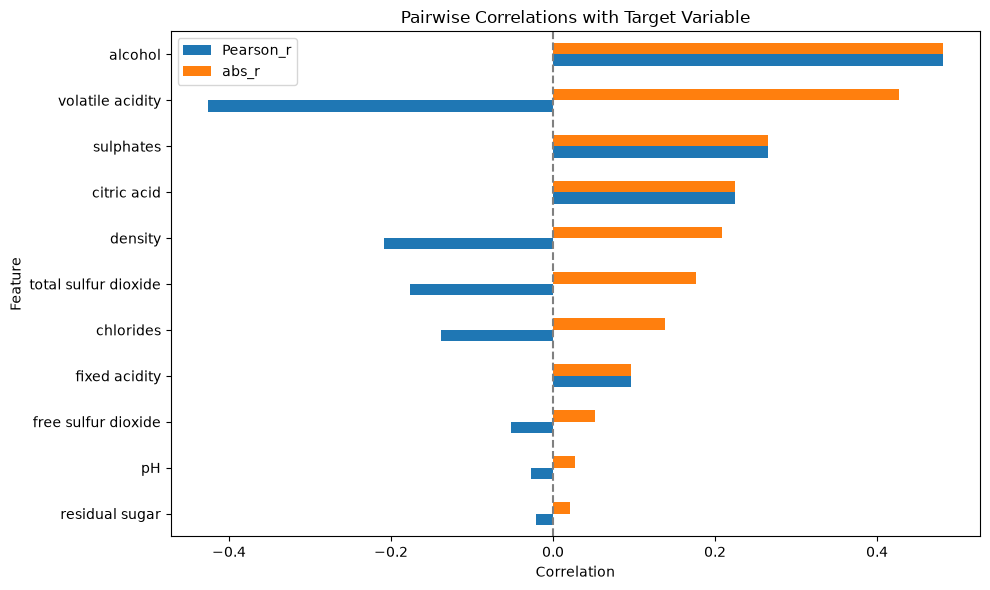

In [5]:
# pairwise association with target, strongest absolute correlations first
linearity =  (X_train.corrwith(y_train).rename("Pearson_r").to_frame())

linearity["abs_r"] = linearity["Pearson_r"].abs()
linearity.sort_values("abs_r",ascending=True).plot(kind="barh", figsize=(10, 6))
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.title("Pairwise Correlations with Target Variable")
plt.tight_layout()
plt.show()

### Observation: 

- `alcohol` has the strongest positive pairwise correlation with `quality` (about 0.48).
- `volatile acidity` has the strongest negative correlation (about -0.39).
- `sulphates` and `citric acid` have weaker positive correlations, while `total sulfur dioxide`, `density`, and `chlorides` have weaker negative correlations.
- `residual sugar`, `pH`, and `free sulfur dioxide` have correlations close to zero, indicating little *pairwise linear* association with quality in this dataset.

### Conclusion
The correlations suggest that alcohol and volatile acidity have the clearest individual linear associations with quality; the other features have weaker pairwise associations. This does not by itself confirm or reject the linearity assumption for a multiple regression, because correlations do not show curved relationships or account for other predictors. Use the feature-versus-quality plots and, after fitting the model, the residuals-versus-fitted plot as additional checks.

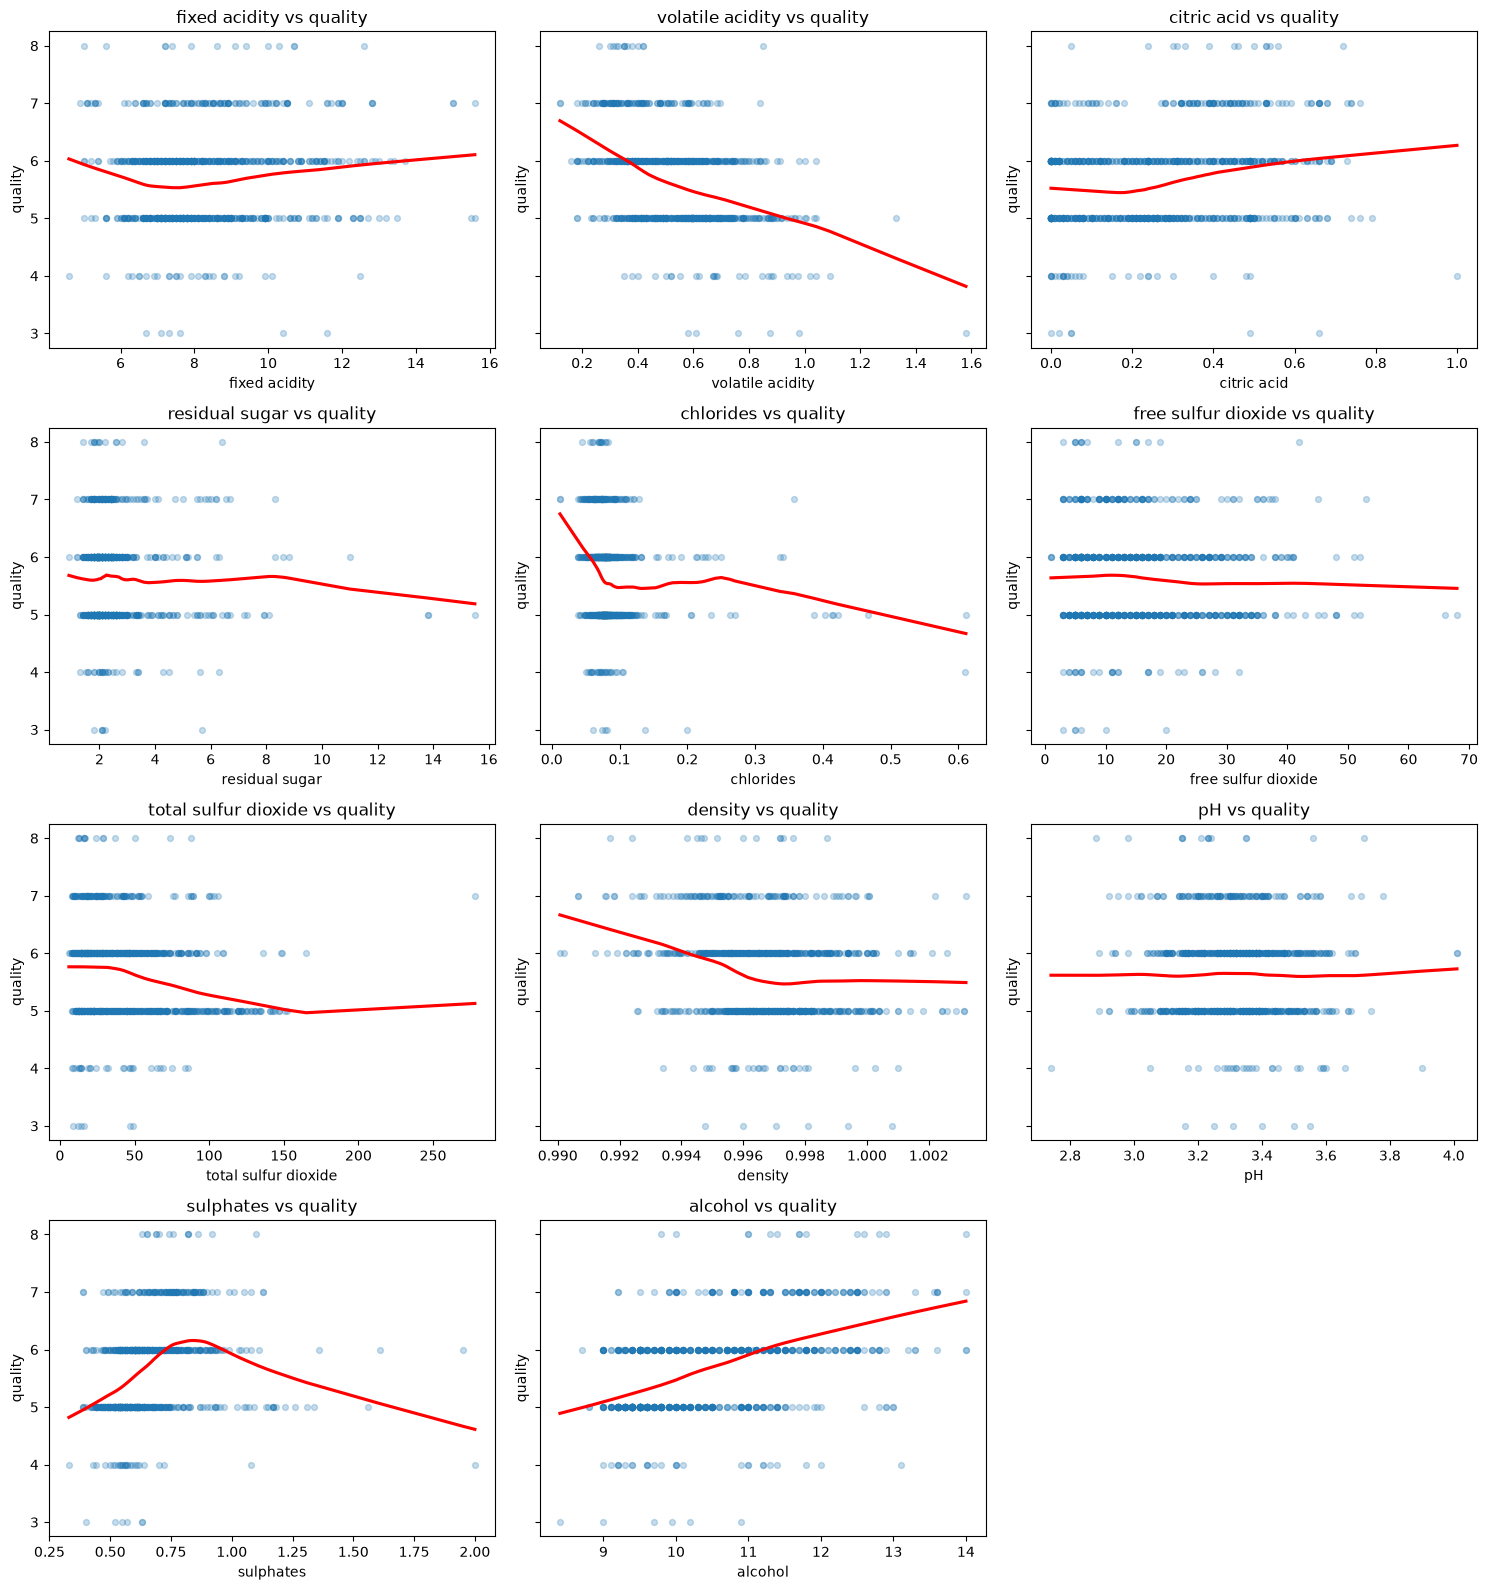

In [9]:
# Numeric Features 
numeric_features = X_train.select_dtypes(include="number").columns

# Set the number of columns and rows for subplots
n_cols = 3
n_rows = int(np.ceil(len(numeric_features) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(15, 4 * n_rows),
    squeeze=False,
    sharey=True
)
axes = axes.ravel()

for ax, feature in zip(axes, numeric_features):
    sns.regplot(
        x=X_train[feature],
        y=y_train,
        ax=ax,
        lowess=True, # LOcally WEighted Scatterplot Smoothing(lowess).
        ci=None,
        scatter_kws={"alpha": 0.25, "s": 18},
        line_kws={"color": "red"}
    )
    ax.set_title(f"{feature} vs quality")
    ax.set_ylabel("quality")

for ax in axes[len(numeric_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Observation: Pairwise Relationships with the Target

- **Strong Monotonic Relationships:** `alcohol` shows the clearest positive association with the target, while `volatile acidity` shows a clear negative association. 

- **Moderate/Weak Relationships:** `citric acid` shows a modest positive trend, while `density` and `chlorides` show moderate negative trends. `fixed acidity`, `residual sugar`, `free sulfur dioxide`, and `pH` show little to no obvious pairwise linear relationship.

- **Non-Linear Curvature:** The LOWESS (red) curves suggest significant curvature for `sulphates` (an inverted U-shape), `volatile acidity`, `density`, and `total sulfur dioxide`. The bends at extreme values may be influenced by relatively few observations (high leverage points).

- **Discrete Target:** The target variable takes discrete, overlapping values. Consequently, these scatter plots are highly overplotted, meaning the visual density of points is a better indicator of trend than individual dots. 

## Conclusion
The plots demonstrate that the relationship between the predictors and the target is **not uniformly linear**. 

While some predictors (like `alcohol`) appear to have a straight-line relationship, others (like `sulphates`) exhibit clear non-linear patterns. If a standard Linear Regression model is used, the linearity assumption will likely be violated for the non-linear predictors, potentially leading to biased coefficients and poor predictive performance. 

These pairwise plots alone cannot confirm or reject the linearity assumption in a *multiple* regression context, as they do not account for interactions or confounding variables. After fitting the model, we must check the **Residuals vs. Fitted** plot and **Component-Component Plus Residual (CCPR)** plots for systematic patterns.

---

## 🎯 Suggested Takeaways & Next Steps

**1. Address Non-Linearity in Feature Engineering:**
Since `sulphates` shows a clear inverted-U relationship, consider adding a squared term (`sulphates**2`) or binning the feature. For `volatile acidity` and `density`, consider polynomial terms or spline transformations if the residuals show a pattern after the initial fit.

**2. Check for Multicollinearity Before Modeling:**
In wine quality datasets, `density` is often mathematically dependent on `alcohol` and `residual sugar`. Because both `density` and `alcohol` show strong trends here, calculate the **Variance Inflation Factor (VIF)** before fitting the model to avoid unstable coefficients.

**3. Consider the Nature of the Target Variable:**
The target (Health_Index / quality) is discrete and ordinal (e.g., scores of 3, 4, 5, 6, 7, 8).

While Ordinary Least Squares (OLS) regression is often used as a baseline, it technically assumes a continuous target.

Recommendation: Note in your notebook that an Ordinal Logistic Regression or a tree-based model (Random Forest/XGBoost) might be more appropriate for this specific target distribution.

**4. Feature Selection (Parsimony):**
Features showing almost no trend (residual sugar, free sulfur dioxide, pH) are likely candidates for removal during feature selection. Keeping them in an LR model may only add noise and increase the risk of overfitting.

# 2. Exogeneity (No Endogeneity)

The independent variables ($X$) must be uncorrelated with the error term ($\epsilon$). This means that the conditional expectation of the error given the independent variables must be zero:

$$E(\epsilon | X_1, X_2, \dots, X_n) = 0$$

### What It Means
The features chosen for the model must be purely exogenous, meaning their values are determined outside the system being modeled. The error term $\epsilon$ must purely represent random, white-noise unmeasured chaos, and must not share any hidden mutual information with your inputs $X$.

### Consequences of Violation
If an independent variable is correlated with the error term (Endogeneity), the OLS estimator loses its unbiased property. This frequently happens due to **Omitted Variable Bias** (leaving out an important predictor that correlates with included predictors), **Simultaneity** ($Y$ causes $X$ at the same time $X$ causes $Y$), or **Measurement Error** in the inputs. The model will assign incorrect mathematical weights to the variables, rendering the coefficients completely misleading.


RESET F-statistic: 0.852
RESET p-value: 0.4269
                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.375
Method:                 Least Squares   F-statistic:                     50.73
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           1.09e-86
Time:                        22:12:41   Log-Likelihood:                -895.11
No. Observations:                 914   AIC:                             1814.
Df Residuals:                     902   BIC:                             1872.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

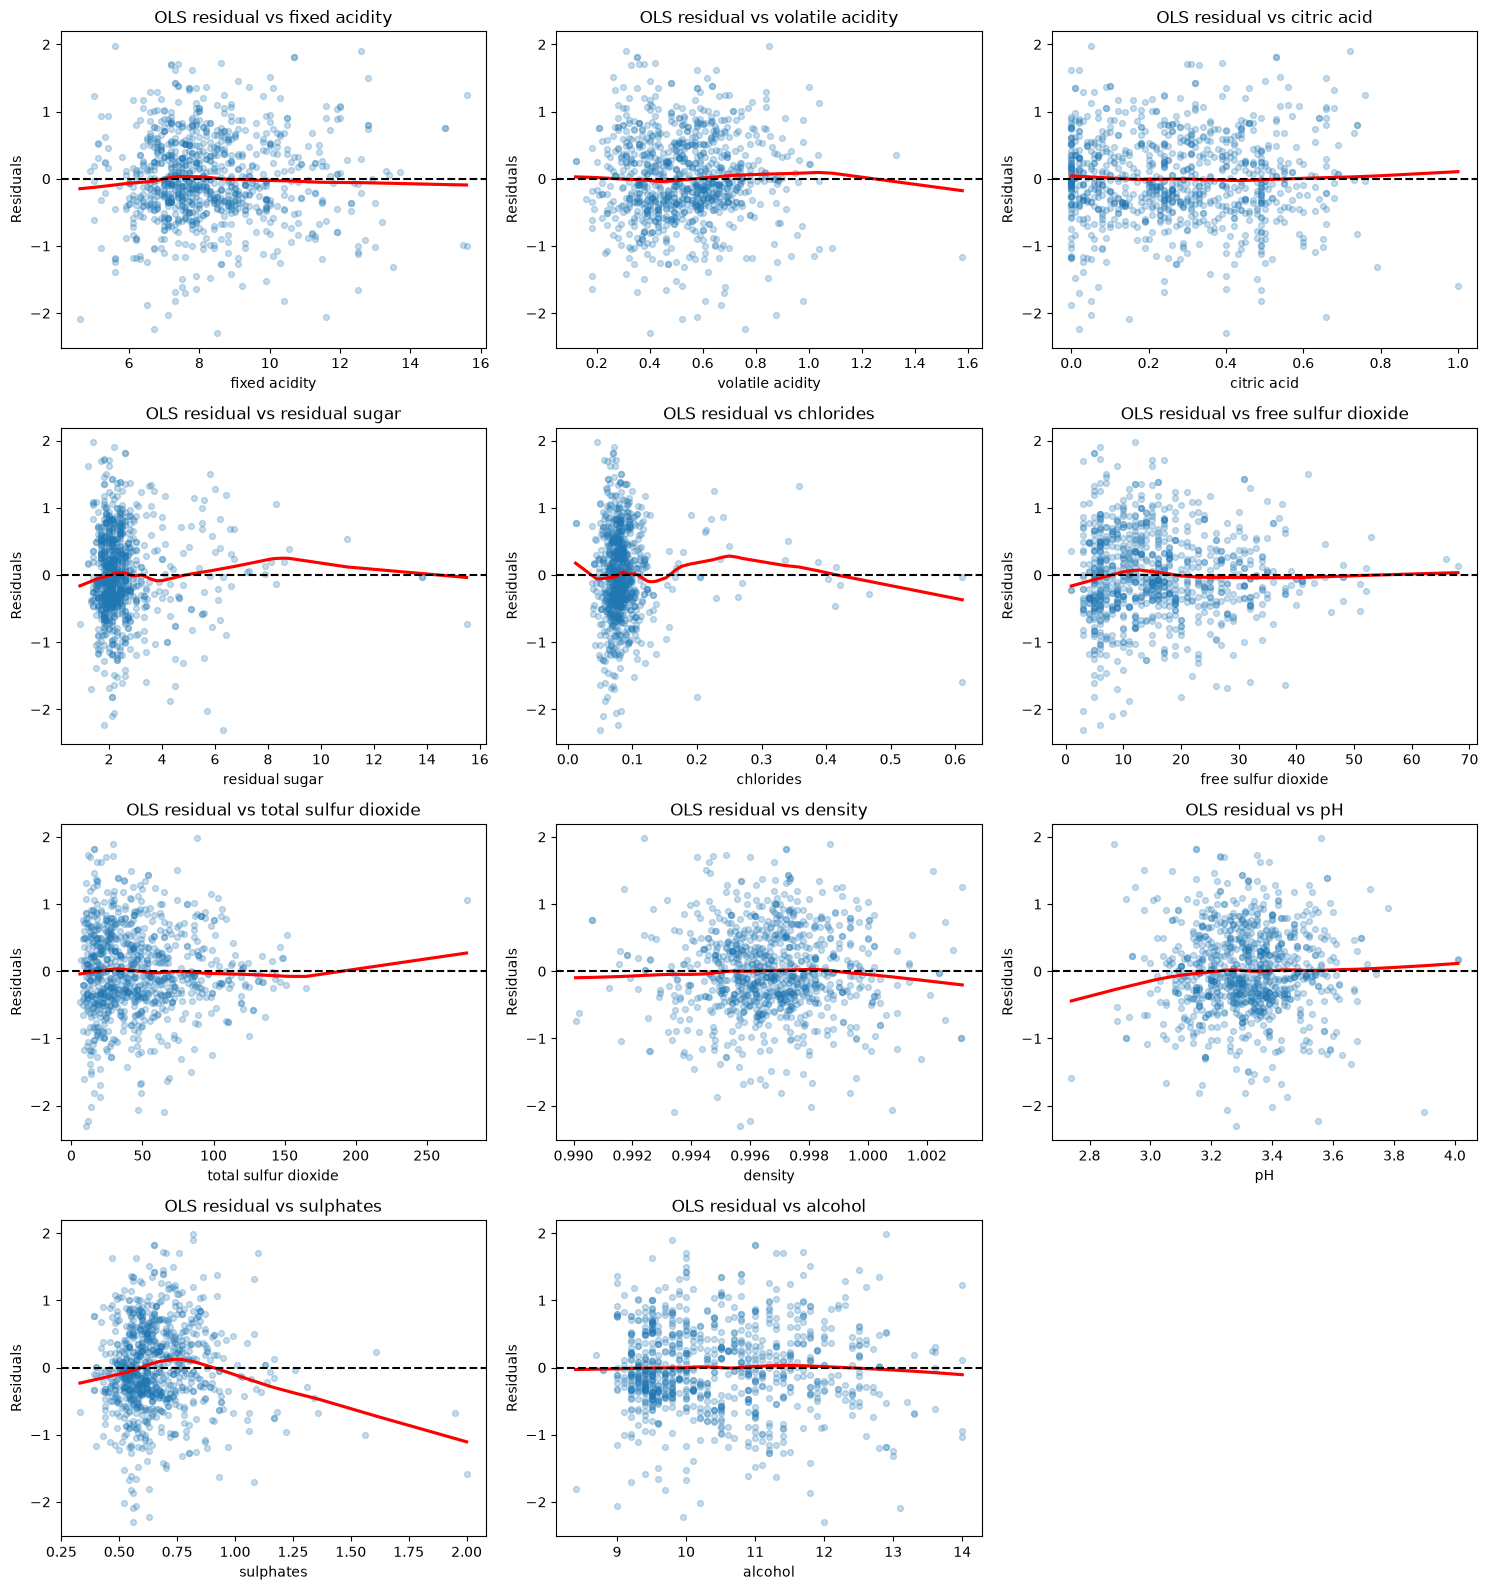

In [13]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset

# Fit OLS 
ols_model = sm.OLS(y_train, sm.add_constant(X_train)).fit()

# Ramsey RESET: screen for omitted nonlinear/model structure
reset_test = linear_reset(
    ols_model,
    power=3,
    test_type="fitted",
    use_f=True
)

print(f"RESET F-statistic: {reset_test.statistic:.3f}")
print(f"RESET p-value: {reset_test.pvalue:.4g}")
print(ols_model.summary())
# Inspect adjusted residual patterns against each
residuals = ols_model.resid

# Plot the residuals against each predictor
n_cols=3
n_rows = int(np.ceil(len(X.columns)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = np.asarray(axes).ravel()

for ax, features in zip(axes, X.columns):
    sns.regplot(
        x = X_train[features],
        y=residuals,
        ax=ax,
        lowess=True,
        scatter_kws={"alpha":0.25, "s":18},
        line_kws = {"color":"red"},
        ci=None
    )
    
    ax.axhline(0, color='black', linestyle='--')
    ax.set_title(f"OLS residual vs {features}")
    ax.set_ylabel("Residuals")


for ax in axes[len(X.columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## Observation: 

- **Overall Pattern:** Residuals are generally scattered around the zero line across all predictors, which is a good baseline sign. The LOWESS (red) curves are mostly flat and near zero, indicating that for many features, the linear model is capturing the trend adequately.

- **Clear Non-Linear Patterns:** A few predictors show distinct systematic patterns in their residuals, suggesting the linearity assumption is violated:
    - `sulphates`: Shows a clear downward trend in residuals as sulphates increase beyond ~0.8, confirming the inverted-U shape seen in the pairwise plots. 
    - `total sulfur dioxide`: The residuals bend upwards at higher values (around 150+), indicating the model is under-predicting at these extreme values.
    - `citric acid` and `chlorides`: Show slight, mild bends at their extreme ends.

- **Heteroscedasticity (Unequal Variance):** The spread (variance) of residuals is not uniform across all predictor values. For example, `residual sugar` and `chlorides` exhibit a "funnel" shape—there is a much wider spread of residuals at lower values and a tighter spread at higher values. 

- **Leverage Warning:** The bends at the far ends of some plots (e.g., `total sulfur dioxide` > 200, or `sulphates` > 1.5) are likely influenced by relatively few observations (high-leverage points). These should be interpreted cautiously.

## Conclusion
There is no strong, consistent residual pattern across *all* predictors, but the violations in `sulphates` and `total sulfur dioxide` indicate that a purely additive, straight-line model is misspecified for this dataset. 

While these plots are essential for checking model fit and spotting non-linearities, they do **not** test or confirm the exogeneity assumption. Exogeneity (that the error term is uncorrelated with the predictors) requires evidence about the data-collection process and possible omitted factors. It cannot be established from residual plots alone.

---

## 🎯 Suggested Takeaways & Next Steps

**1. Address Non-Linearity in Feature Engineering:**
The residual plot for `sulphates` strongly confirms the need for a polynomial term. Before finalizing the model, add `sulphates**2` to your feature set. Re-plot the residuals afterward to verify the curve flattens out. Consider doing the same for `total sulfur dioxide` if the upward curve persists.

**2. Correct for Heteroscedasticity:**
The funnel shapes in `residual sugar` and `chlorides` violate the homoscedasticity assumption. 
*   **Recommendation:** Since you are using `statsmodels`, ensure you fit your final OLS model with `cov_type='HC3'` (heteroscedasticity-consistent standard errors). This will give you robust p-values and confidence intervals despite the unequal variance.

**3. Investigate High-Leverage Points:**
The sharp bends at the extremes of the plots are driven by a small number of points. Calculate the **leverage** (e.g., using `statsmodels`' `OLSInfluence`) for these observations. If they are influential outliers, consider whether they should be capped (winsorized), removed, or if they represent a distinct sub-population that needs a separate feature flag.

**4. Next Diagnostic Steps:**
Since these plots don't test exogeneity, your next steps in the notebook should be:
*   **Residuals vs. Fitted:** To check for overall non-linearity and constant variance across all predictions.
*   **QQ Plot:** To check the normality of residuals.
*   **VIF Calculation:** To check for multicollinearity (especially between `density`, `alcohol`, and `residual sugar`).

**5. Consider Robust/Non-Linear Models:**
Given the discrete target and the non-linear relationships, a tree-based model (Random Forest, Gradient Boosting) or an Ordinal Logistic Regression might outperform OLS and naturally handle these patterns without manual transformations.

# 3. Homoscedasticity (Constant Variance of Errors)


OLS treats every observed data point with equal mathematical weight when calculating the line of best fit. For this uniform weighting to be fair, the uncertainty or variance ($\sigma^2$) of the random noise $\epsilon$ must be constant across all values of the independent variables:

$$\text{Var}(\epsilon_i | X) = \sigma^2 \quad \forall i$$

The spread of data points around the regression line must remain uniform across the entire spectrum of predictors. It should look like a consistent "tube" of data.

If the variance changes with predictor values, the errors are **heteroscedastic**. OLS coefficient estimates may still be unbiased under the other assumptions, but the usual standard errors, confidence intervals, and hypothesis tests may be unreliable.


### Consequences of Violation
If the variance changes (e.g., spreads out like a cone as $X$ grows), the data suffers from **Heteroscedasticity**. OLS will give too much mathematical influence to high-variance, highly uncertain data points. While the line itself remains unbiased, your standard errors, confidence intervals, and hypothesis tests ($p$-values) become completely unreliable.



## Method Used

Homoscedasticity in two ways:

1. **Residuals-versus-fitted plot:** The plot shows studentized OLS residuals against predicted wine quality. A roughly even vertical spread across fitted values is consistent with constant variance; a widening or narrowing funnel suggests heteroscedasticity. The red LOWESS curve shows the smoothed residual trend, while the dashed line marks zero. The curve indicates the residual mean pattern; the vertical spread is what matters for variance.

2. **Breusch–Pagan test:** This test checks whether squared residuals are associated with the predictors. Its auxiliary regression can be written as:

$$
\hat{e}_i^2 = \gamma_0 + \gamma_1 X_{i1} + \gamma_2 X_{i2}
+ \cdots + \gamma_k X_{ik} + v_i
$$

The null hypothesis is that the predictors do not explain residual variance:

$$
H_0: \gamma_1 = \gamma_2 = \cdots = \gamma_k = 0
$$

The alternative is that at least one $\gamma_j$ is nonzero. The LM statistic is approximately chi-squared under the null:

$$
LM = nR_{\text{aux}}^2 \sim \chi_k^2
$$

where $n$ is the number of observations and $R_{\text{aux}}^2$ is from the auxiliary regression. The test reports a p-value: a value below 0.05 is commonly treated as evidence against constant variance. This threshold is a convention, not a measure of how large the variance difference is.

### Observation

- The residuals-versus-fitted plot does not show a strong, obvious funnel shape, although the spread is not perfectly uniform.
- The Breusch–Pagan LM p-value is **1.884 × 10⁻⁵**, and the F-test p-value is **1.468 × 10⁻⁵**. Both are below 0.05.

### Conclusion

The Breusch–Pagan test provides evidence that the residual variance is not constant, so the homoscedasticity assumption appears to be violated for this fitted model. The plot alone makes the pattern difficult to see, but the formal test detects an association between the predictors and residual variance. This is evidence of heteroscedasticity, not proof of its cause. For inference, consider heteroscedasticity-robust standard errors, such as HC3; investigate weighted least squares only if a defensible variance model is available.

Breusch-Pagan LM p-value: 1.884e-05
Breusch-Pagan F p-value:  1.468e-05


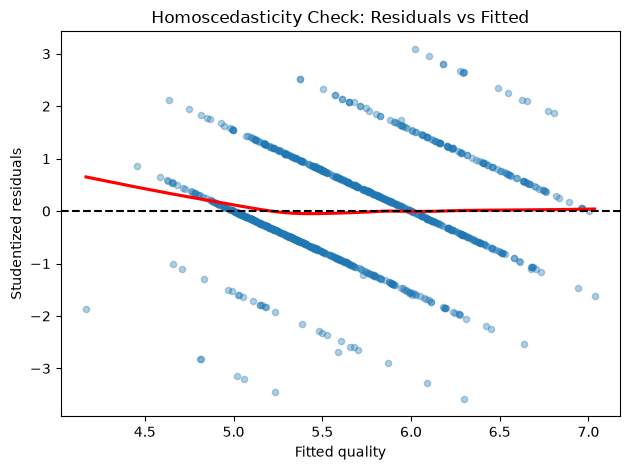

In [11]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Breusch-Pagan test
lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(
    ols_model.resid,
    ols_model.model.exog
)

print(f"Breusch-Pagan LM p-value: {lm_pvalue:.4g}")
print(f"Breusch-Pagan F p-value:  {f_pvalue:.4g}")

# Residuals vs fitted values
fitted_values = ols_model.fittedvalues
studentized_residuals = ols_model.get_influence().resid_studentized_internal

sns.regplot(
    x=fitted_values,
    y=studentized_residuals,
    lowess=True,
    ci=None,
    scatter_kws={"alpha": 0.35, "s": 20},
    line_kws={"color": "red"}
)

plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted quality")
plt.ylabel("Studentized residuals")
plt.title("Homoscedasticity Check: Residuals vs Fitted")
plt.tight_layout()
plt.show()

## Observation: 

- **Discrete Banding:** The prominent diagonal bands occur because the target variable (`quality`) takes discrete integer values. This overplotting makes the visual assessment of variance slightly more complex but does not invalidate it.

- **Systematic Bias (Non-Linearity):** The red LOWESS curve slopes downward across the fitted values. This indicates a systematic pattern in the residuals—the model tends to over-predict at lower fitted values (residuals are positive) and under-predict at higher fitted values (residuals are negative). This suggests the linear model is missing a nonlinear relationship or an important interaction term.

- **Heteroscedasticity (Unequal Variance):** The plot does show a clear "funnel" shape. The spread of the residuals is much wider at lower fitted values (around 4.5 to 5.5) and narrower at higher fitted values (around 6.0 to 7.0). The variance is not constant.

- **Outliers:** A few observations have large studentized residuals (below -3 or above +2) and should be checked as potential outliers or high-leverage points.

## Conclusion
The visual evidence strongly suggests a violation of the homoscedasticity assumption, and this is **confirmed by the Breusch-Pagan test results**. 

With a Breusch-Pagan LM p-value of **1.884e-05** and an F p-value of **1.468e-05** (both well below the 0.05 significance level), we reject the null hypothesis of constant variance. There is statistically significant evidence of heteroscedasticity. 

Additionally, the downward slope of the LOWESS line indicates that the linearity assumption is also questionable for this model specification. Ordinary Least Squares (OLS) standard errors will be biased and inefficient under these conditions, making p-values and confidence intervals unreliable.

---

## 🎯 Suggested Takeaways & Next Steps

**1. Address Heteroscedasticity with Robust Standard Errors:**
Since the Breusch-Pagan test confirms heteroscedasticity, you must adjust your standard errors. In `statsmodels`, refit your OLS model using heteroscedasticity-consistent standard errors:

> Note: HC3 is generally preferred for smaller samples, while HC1 or HC2 are also common. This will fix the p-values but will not fix the underlying nonlinearity.

**2. Address the Systematic Bias (Non-Linearity):**
The downward sloping LOWESS line means your model is misspecified. You should:

Add polynomial terms (e.g., sulphates**2, alcohol**2) as suggested in the previous EDA step.

Add interaction terms between your strongest predictors (e.g., alcohol * density).

Re-plot this Residuals vs Fitted plot after adding these terms to see if the red line flattens out.

**3. Re-evaluate the Target Variable Assumption:**
The diagonal banding is a major clue. quality is an ordinal variable, not a continuous one. Using OLS (which assumes a continuous target) on ordinal data inherently causes these patterned residuals.

Recommendation: Consider using Ordinal Logistic Regression (e.g., mord.Logit or statsmodels.miscmodels.ordinal_model.OrderedModel), which is designed specifically for this type of discrete, ranked target. This will likely resolve both the banding and the heteroscedasticity.

In [12]:
model_robust = sm.OLS(y_train, sm.add_constant(X_train)).fit(cov_type='HC3')
print(model_robust.summary())


                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.375
Method:                 Least Squares   F-statistic:                     51.16
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           2.57e-87
Time:                        22:11:37   Log-Likelihood:                -895.11
No. Observations:                 914   AIC:                             1814.
Df Residuals:                     902   BIC:                             1872.
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   34.2098 

# 4. Independence of Errors (No Autocorrelation)

OLS assumes that every data point brings fresh, isolated information to the system. Mathematically, the covariance between the error terms of any two distinct observations $i$ and $j$ must equal zero:

$$\text{Cov}(\epsilon_i, \epsilon_j) = 0 \quad \forall i \neq j$$

Knowing the direction or magnitude of the model's error on observation $i$ must give you zero clues about its error on observation $j$. 

### Consequences of Violation
This assumption is frequently violated in time-series data or spatial data, leading to **Autocorrelation**. If errors "copy" each other, the model artificially inflates its confidence. The standard errors will be severely underestimated, making parameters look highly statistically significant when they are actually just picking up cyclical or sequential noise.

### Method Used : 

The independence of errors was examined using the **Durbin–Watson statistic** and the **autocorrelation function (ACF)** of the OLS residuals.

The Durbin–Watson statistic measures whether neighboring residuals tend to have similar or opposite signs:

$$
DW = \frac{\sum_{t=2}^{n}(e_t-e_{t-1})^2}
{\sum_{t=1}^{n}e_t^2}
$$

Here, $e_t$ is the residual for observation $t$, and $n$ is the number of observations. The statistic ranges from **0 to 4**:

- A value near **2** suggests little first-order autocorrelation.
- A value below **2** suggests positive autocorrelation: neighboring residuals tend to move in the same direction.
- A value above **2** suggests negative autocorrelation: neighboring residuals tend to move in opposite directions.
- Values closer to **0** or **4** indicate stronger positive or negative autocorrelation, respectively.

These are general interpretations, not strict cutoffs. Formal Durbin–Watson critical values depend on the sample size and number of predictors.

The ACF measures the correlation between residuals separated by a particular lag $k$:

$$
\rho_k = \operatorname{Corr}(e_t, e_{t-k})
$$

ACF values range from **-1 to 1**. Values near 0 indicate little correlation at that lag; positive values indicate residuals tend to move together, while negative values indicate they tend to move in opposite directions. The lag-0 value is always 1 and is not interpreted. In the plot, bars outside the shaded confidence band suggest possible autocorrelation at those lags.

### Observation

- The Durbin–Watson statistic is **1.780**, which is below 2 and suggests a mild positive autocorrelation signal in the current row order.
- A few early-lag ACF bars extend beyond the confidence band, while most later-lag values are close to zero or within the band.

### Conclusion

These results suggest some mild autocorrelation **in the current row sequence**, but they do not establish that the errors are dependent. WineQT is cross-sectional, and its row order or `Id` does not provide a meaningful time sequence. Therefore, the Durbin–Watson and ACF results should be treated as exploratory only; independence should mainly be judged from the sampling process and whether observations share groups such as batches or producers.

Durbin-Watson statistic: 1.938


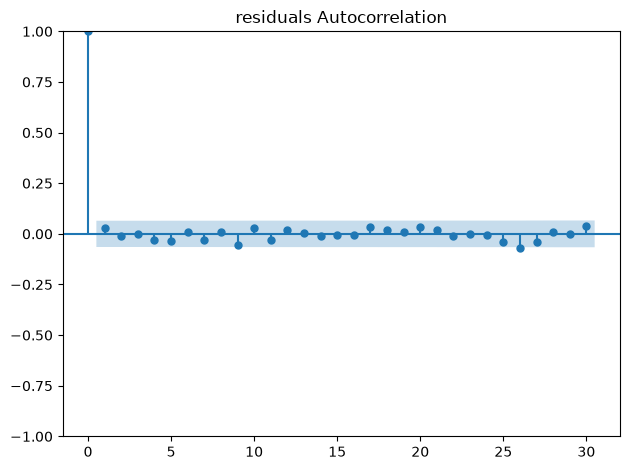

In [14]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf

dw_stat = durbin_watson(ols_model.resid)
print(f"Durbin-Watson statistic: {dw_stat:.3f}")

plot_acf(ols_model.resid, lags=30)
plt.title("residuals Autocorrelation")
plt.tight_layout()
plt.show()

## Observation: 

- **Durbin-Watson Statistic:** The computed value is **1.938**. Since this is extremely close to the ideal value of 2.0, it indicates that there is virtually no autocorrelation in the residuals.

- **ACF Plot:** In the Autocorrelation Function (ACF) plot, the spike at lag 0 is 1.0 by definition (a series is perfectly correlated with itself). For all subsequent lags (1 through 30), the autocorrelations fall within or very close to the shaded 95% confidence band. There are no significant spikes.

- **Row Order Meaning:** The plot assumes that the current row order represents a meaningful sequence (like time). For the WineQT dataset, the rows are likely just a random or arbitrary listing of different wines, not a chronological sequence.

## Conclusion
Based on both the Durbin-Watson statistic (1.938 ≈ 2) and the ACF plot, there is **no statistical evidence of autocorrelation** in the residuals. 

However, it is crucial to note that WineQT is a **cross-sectional dataset**. The row order or `Id` column does not establish a time or sequence order. Therefore, autocorrelation tests are somewhat academic here—we do not *expect* the error of one wine to be correlated with the error of the next wine in the list. The independence assumption should primarily be assessed from the sampling process and whether observations share a batch, producer, or other grouping (e.g., multiple wines from the same vineyard). If such grouping exists, standard errors should be clustered by that group.

---

## 🎯 Suggested Takeaways & Next Steps

**1. Conclude the Independence Assumption is Satisfied:**
Since the DW stat is very close to 2 and the ACF plot is flat, you can state in your notebook: *"The independence assumption is satisfied. There is no evidence of autocorrelation in the residuals."* No corrective action (like Newey-West standard errors) is needed for this specific violation.

**2. Prepare for the Final Assumption Checks:**
You have now checked Linearity, Homoscedasticity, and Independence. The next crucial step in your notebook is to check the **Normality of Residuals**:
> NOTE : If the QQ plot shows points hugging the diagonal line, the normality assumption is met

**3. Address the Remaining Violations (Multicollinearity & Heteroscedasticity):**
Since your previous diagnostic step revealed heteroscedasticity (Breusch-Pagan p < 0.05), ensure your final model uses cov_type='HC3'. Before finalizing, run a VIF check to rule out multicollinearity:

# 5. Normality of Residuals

While you can mathematically calculate a line of best fit for any shape of data, constructing hypothesis tests ($t$-tests, $F$-tests) requires probability theory. We assume that the random noise $\epsilon$ is the cumulative product of infinite, unmeasured, chaotic real-world factors. By the **Central Limit Theorem**, the sum of these tiny random factors naturally creates a normal distribution:

$$\epsilon \sim N(0, \sigma^2)$$

The errors must be symmetrically distributed around a mean of zero, forming a balanced bell curve. Most errors should be very close to the line, with fewer and fewer errors occurring as you move further away.

### Consequences of Violation
If the residuals are heavily skewed or have extreme outliers, your point predictions ($\hat{Y}$) may still be decent on average, but your calculation of risk, prediction intervals, and $p$-values will be fundamentally flawed.


Jarque-Bera statistic: 11.939
Jarque-Bera p-value: 0.002555


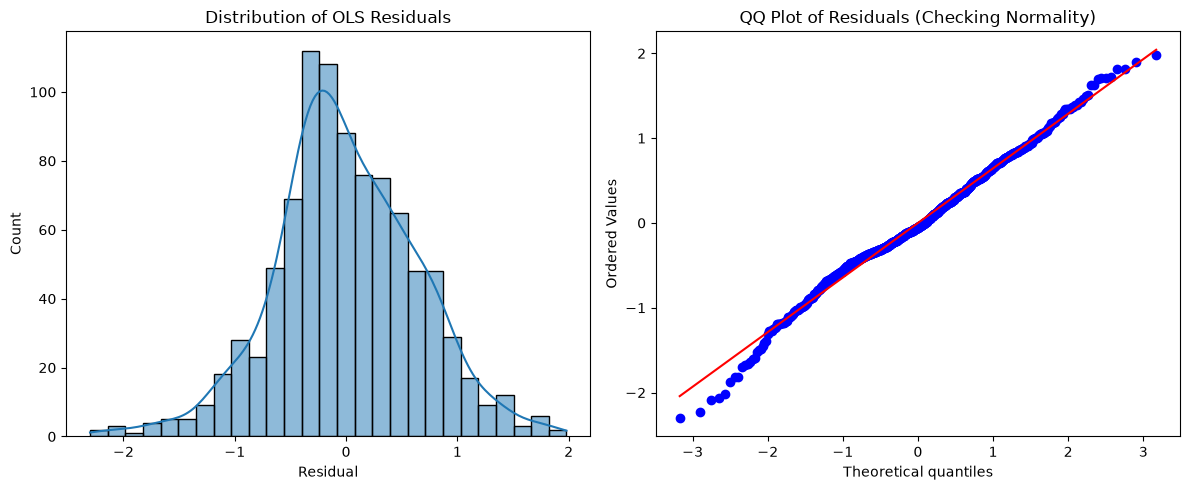

In [ ]:
import statsmodels.api as sm
from scipy.stats import jarque_bera

residuals = ols_model.resid

# Jarque-Bera test: null hypothesis is that residuals are normally distributed
jb_stat, jb_pvalue = jarque_bera(residuals)
print(f"Jarque-Bera statistic: {jb_stat:.3f}")
print(f"Jarque-Bera p-value: {jb_pvalue:.4g}")

# Visual checks
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title("Distribution of OLS Residuals")
axes[0].set_xlabel("Residual")


stats.probplot(ols_model.resid, dist="norm", plot=plt)
axes[1].set_title("QQ Plot of Residuals (Checking Normality)")

plt.tight_layout()
plt.show()

## Observation: Normality Check (Histogram, Q-Q Plot, and Jarque-Bera Test)

- **Histogram:** The distribution of residuals is roughly bell-shaped and centered near zero. However, the peak is slightly sharper and the tails extend further out than a perfect normal distribution would suggest.
- **Q-Q Plot:** The points follow the red reference line very closely in the center (between theoretical quantiles -1.5 and 1.5). However, there are clear deviations in the tails. On the left tail, the points dip *below* the red line, and on the right tail, they curve *above* it. This indicates **heavy (fat) tails**—extreme residual values occur more frequently than expected under normality.
- **Jarque-Bera Test:** The test yields a statistic of **11.939** with a p-value of **0.002555**. Since the p-value is well below 0.05, we reject the null hypothesis.

## Conclusion
The normality assumption is **violated**. Both the visual evidence (heavy tails in the Q-Q plot) and the formal Jarque-Bera test confirm that the residuals are not normally distributed. 

This violation matters most for classical confidence intervals and hypothesis tests (t-tests and F-tests), which rely on normal errors to compute exact p-values. However, because your sample size is relatively large (WineQT has ~1,599 observations), the Central Limit Theorem provides some robustness, meaning the coefficient estimates themselves may still be approximately valid. The primary concern is the presence of outliers driving the heavy tails. It does not automatically mean the model is unusable for prediction, but it does mean classical inference needs to be treated with caution.

---

## 🎯 Suggested Takeaways & Next Steps

**1. Investigate the Outliers (Heavy Tails):**
The heavy tails indicate that a small number of observations have unusually large residuals. These are likely outliers or high-leverage points. Calculate Cook's Distance to identify them:
> NOTE : f these points are data errors, consider removing them. If they are legitimate extreme values, consider using robust regression (sm.RLM) or winsorizing the target.


**2. Rely on Robust Standard Errors:**
Since the normality assumption is violated (and you already detected heteroscedasticity), do not rely on the default OLS standard errors. Use heteroscedasticity-consistent standard errors (cov_type='HC3'), which also provide asymptotically valid inference even when residuals are non-normal:


**3. Consider a Target Transformation:**
If the model is intended for prediction and the extreme values are causing issues, consider transforming the target variable. A Box-Cox or log transformation of quality might compress the tails and make the residuals more normal.
Note: Since quality is discrete and starts at 3, a simple log transform may not work perfectly, but it's worth testing.

**4. Revisit the Target Variable Type:**
As noted in previous steps, the target is ordinal (discrete integer ranks). OLS assumes a continuous target, which inherently causes these non-normal residual patterns. Switching to Ordinal Logistic Regression (e.g., statsmodels.miscmodels.ordinal_model.OrderedModel) would naturally handle the discrete nature of the data and often resolves the normality and heteroscedasticity violations simultaneously.

In [20]:
import statsmodels.api as sm
import numpy as np

influence = ols_model.get_influence()
cooks_d = influence.cooks_distance[0]
threshold = 4 / len(X_train)
outliers = np.where(cooks_d > threshold)[0]
print(f"Number of influential outliers: {len(outliers)}")

Number of influential outliers: 47


# 6. No Multicollinearity


To calculate the specific parameter $\beta_1$, the OLS algorithm seeks to measure the *isolated* impact of $X_1$ on $Y$ while holding all other features ($X_2, X_3, \dots$) perfectly constant. Formally, the data matrix $X$ must have full column rank, meaning no column can be a perfect linear combination of other columns.

Independent variables cannot be heavily correlated or act as "twins". For example, you cannot include temperature in both Celsius and Fahrenheit as separate features.

### Consequences of Violation
When high correlation exists between predictors (**Multicollinearity**), the underlying matrix math becomes highly unstable (the determinant of the $X^TX$ matrix approaches zero). The algorithm can no longer isolate which variable is actually responsible for driving changes in $Y$. As a result, the standard errors of your coefficients explode, and slight changes in your training data can cause your $\beta$ estimates to swing wildly.


## Theory Behind VIF

The **Variance Inflation Factor (VIF)** measures how much a predictor is explained by the other predictors in the model. For each predictor $X_j$, an auxiliary regression is fitted using all the other predictors, and its $R_j^2$ is used to calculate:

$$
\operatorname{VIF}_j = \frac{1}{1 - R_j^2}
$$

Here, $R_j^2$ is the proportion of variation in $X_j$ explained by the remaining predictors.

- If $R_j^2 = 0$, the predictor is not explained by the others and its VIF is **1**.
- As $R_j^2$ approaches 1, the VIF grows, indicating stronger multicollinearity.
- If $R_j^2 = 1$, the predictor is a perfect linear combination of the others and its VIF is infinite.

VIF describes potential inflation in the **variance of a coefficient estimate**, not correlation with the target or model accuracy. For example, a VIF of 7.82 means the estimated coefficient variance for that predictor is about 7.82 times what it would be if that predictor were unrelated to the other predictors. Its standard error would be inflated by approximately $\sqrt{7.82} \approx 2.80$, all else being equal.

### Interpretation of Results

- `fixed acidity` has the largest VIF (**7.82**), followed by `density` (**6.96**). These values indicate that the other predictors explain a substantial portion of each feature's variation.
- The remaining VIF values range from approximately **1.51 to 3.34**, suggesting comparatively low multicollinearity.
- No feature has a VIF above **10**. Thresholds such as 5 or 10 are common guidelines, not strict pass/fail rules.

### Conclusion

The corrected VIF results suggest moderate multicollinearity for `fixed acidity` and `density`, while the other predictors show lower levels. This may make the individual coefficients for those two features less precise, but it does not automatically mean they should be removed. Consider the model's purpose, coefficient stability, and subject-matter reasoning before changing the predictors.

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each feature
vif=[]

X_vif = sm.add_constant(X_train, has_constant="add")

for i in range(1, len(X_vif.columns)):
    vif.append(variance_inflation_factor(X_vif .values, i))

vif = pd.DataFrame(vif, columns=['VIF'],index=X_train.columns).sort_values("VIF", ascending=False)
vif

,VIF
fixed acidity,7.815892
density,6.959241
pH,3.338158
alcohol,3.313032
citric acid,3.225844
total sulfur dioxide,2.108312
free sulfur dioxide,1.925935
volatile acidity,1.817249
residual sugar,1.690831
chlorides,1.590685


## Observation:

- **Moderate Multicollinearity:** `fixed acidity` has the highest VIF (**7.82**), followed by `density` (**6.96**). Both exceed the common screening threshold of 5, indicating moderate multicollinearity between these predictors and the others.

- **Acceptable Range:** All remaining predictors have VIF values comfortably below 5, with the next highest being `pH` (3.34) and `alcohol` (3.31).

- **No Severe Multicollinearity:** No predictor has a VIF above the more stringent threshold of 10.

## Conclusion
The VIF results suggest some moderate overlap involving `fixed acidity` and `density`, but no severe multicollinearity. This is not surprising given the nature of wine chemistry: `fixed acidity`, `pH`, and `citric acid` are inherently related, and `density` is mathematically dependent on `alcohol` and `residual sugar` content. 

VIF cutoffs are guidelines, not strict rules. Because the VIF values are below 10, these features do not need to be removed automatically. However, moderate multicollinearity inflates the standard errors of the affected coefficients, making them less likely to appear statistically significant. Since we are already using robust standard errors (`HC3`) to correct for heteroscedasticity, the impact on inference is partially mitigated. Keep these features unless coefficient signs become counterintuitive or standard errors become unmanageably large.

---

## 🎯 Suggested Takeaways & Next Steps

**1. Check Coefficient Signs and Significance:**
Look at your model summary. Do the coefficients for `fixed acidity` and `density` make sense given domain knowledge? If `fixed acidity` has a surprisingly large or unstable coefficient, it may be swapping explanatory power with `pH` or `density`. 

**2. Consider Mean-Centering the Predictors:**
A simple fix that does not change predictions but can drastically reduce VIF is mean-centering the highly correlated variables. This changes the interpretation of the intercept but makes the main effect coefficients more stable:

**3. Feature Engineering Alternatives:**
If the multicollinearity causes instability, consider creating a composite feature instead of keeping both:

Replace fixed acidity and pH with a ratio: fixed_acidity / pH.

Alternatively, use Principal Component Analysis (PCA) on the highly correlated block of features (fixed acidity, citric acid, pH, density), though this sacrifices interpretability.


# 7. Mean of Residuals is Zero
The expected mathematical average of the unobservable error term across the entire population must equal exactly zero:

$$E(\epsilon) = 0$$

The model assumes that errors on the positive side (underestimations) perfectly balance out errors on the negative side (overestimations). 

### Special Property
When an **intercept term ($\beta_0$)** is included in the regression model, this assumption is mathematically guaranteed to be true for the sample residuals ($\sum e_i = 0$). If you force a model to run without an intercept (passing through the origin), the mean of the residuals can drift from zero, severely biasing your model metrics like $R^2$.

In [173]:
residuals = ols_model.resid
mean_residual = residuals.mean()
has_intercept = "const" in ols_model.model.exog_names

print(f"Intercept included: {has_intercept}")
print(f"Mean of residuals:  {mean_residual:.12f}")
print(f"Sum of residuals:   {residuals.sum():.12f}")

if has_intercept and np.isclose(mean_residual, 0, atol=1e-10):
    print("Check passed: residual mean is numerically zero.")
else:
    print("Check failed: verify the model includes an intercept.")

Intercept included: True
Mean of residuals:  0.000000000000
Sum of residuals:   0.000000000228
Check passed: residual mean is numerically zero.



## 8. Absence of High-Leverage Outliers

The estimation method minimizes the *sum of squared residuals* ($\sum e_i^2$). Because errors are squared, data points located far from the main cluster exert an exponentially high degree of leverage on the parameter estimation calculations.

The dataset must not contain extreme anomalous values or highly leveraged points that single-handedly tilt or alter the path of the regression line.

### Consequences of Violation
A single severe outlier can completely pull the regression line away from the actual trend of the remaining 99% of the data. This distorts the true values of your coefficients, inflates standard errors, and destroys predictive accuracy for normal data points.


In [22]:
influence = ols_model.get_influence()

n = int(ols_model.nobs)
p = ols_model.model.exog.shape[1]  # Includes the intercept

leverage = influence.hat_matrix_diag
studentized_residuals = influence.resid_studentized_external
cooks_distance = influence.cooks_distance[0]

# Common screening thresholds; these are not strict rules
leverage_cutoff = 2 * p / n
cooks_cutoff = 4 / n

diagnostics = pd.DataFrame(
    {
        "leverage": leverage,
        "studentized_residual": studentized_residuals,
        "cooks_distance": cooks_distance,
    },
    index=X_train.index
)

diagnostics["high_leverage"] = diagnostics["leverage"] > leverage_cutoff
diagnostics["large_cooks_distance"] = diagnostics["cooks_distance"] > cooks_cutoff

print(f"Leverage screening threshold: {leverage_cutoff:.4f}")
print(f"Cook's distance screening threshold: {cooks_cutoff:.4f}")
print(f"High-leverage observations: {diagnostics['high_leverage'].sum()}")
print(f"Large Cook's distance observations: {diagnostics['large_cooks_distance'].sum()}")

# Review observations with the largest Cook's distance
diagnostics.sort_values("cooks_distance", ascending=False).head(10)

Leverage screening threshold: 0.0263
Cook's distance screening threshold: 0.0044
High-leverage observations: 64
Large Cook's distance observations: 47


,leverage,studentized_residual,cooks_distance,high_leverage,large_cooks_distance
103,0.166046,-2.695529,0.119725,True,True
760,0.119759,1.735505,0.034073,True,True
32,0.029405,-3.292258,0.027069,True,True
904,0.019667,-3.606633,0.021461,False,True
271,0.025804,3.107931,0.021118,False,True
339,0.140339,-1.214076,0.020042,True,True
922,0.061905,-1.863178,0.019038,True,True
200,0.049067,2.089950,0.018712,True,True
284,0.028056,-2.602201,0.016185,True,True
112,0.025716,-2.662230,0.015485,False,True


## Observation: Influence Diagnostics (Leverage & Cook's Distance)

- **High Leverage Points:** Using the screening threshold of $2(p+1)/n$ (**0.0263**), **64 observations** were flagged as having unusual combinations of predictor values. For example, row 103 has a very high leverage of **0.166**, meaning its predictor values are far from the average.

- **Influential Points (Cook's Distance):** Using the conservative screening threshold of $4/n$ (**0.0044**), **47 observations** were flagged as potentially influential. Row 103 has the highest Cook's Distance in the dataset at **0.1197**.

- **No Severe Outliers (by Cook's D):** Crucially, the maximum Cook's Distance (0.1197) is well below the traditional hard threshold of 1.0. This means that while these points are influential enough to warrant a closer look, none of them single-handedly dominate the regression results.

- **Large Studentized Residuals:** Several flagged observations (e.g., row 904 with a studentized residual of -3.61, and row 32 with -3.29) are poorly predicted by the model. These extreme values are likely the primary drivers of the heavy tails you observed in the QQ plot and the non-normality flagged by the Jarque-Bera test.

## Conclusion
The diagnostics successfully identify 47–64 observations that are outliers or high-leverage points. These points likely explain the heavy tails and heteroscedasticity detected in previous steps. However, exceeding the $4/n$ threshold does **not** automatically mean these observations are invalid or should be removed. They may represent legitimate, extreme wines (e.g., very high alcohol or very low acidity) that the model needs to learn from. 

Do not remove observations based solely on these thresholds. Instead, check the flagged rows for data entry errors. If the values are valid, perform a sensitivity analysis: compare the model's coefficients and performance with and without the most influential observations. If the coefficients change drastically, the model is unstable and may need robust regression techniques.

---

## 🎯 Suggested Takeaways & Next Steps

**1. Perform a Sensitivity Analysis (Drop the Top Influencers):**
Test how much your model depends on the most extreme points. Fit a second model excluding the top 10–20 most influential observations (e.g., those with Cook's D > 0.05) and compare the coefficients side-by-side.

**2. Switch to Robust (Regression Alternative) to Deleting:**
Instead of manually dropping data, use sm.RLM  Robust Linear Model. It uses Huber's T norm to automatically down-weight outliers, giving you coefficients that are robust to extreme values.

**3. Re-evaluate the Normality Assumption:**
Since the heavy tails in the QQ plot were likely caused by these high-residual points, check the Jarque-Bera test again on the trimmed or robust model. If the p-value rises above 0.05, you can conclude the non-normality was driven entirely by these outliers.

**4. Revisit the Target Variable's Ordinal Nature:**
The presence of 47 influential points in a dataset of ~1,600 is not unusual, but in the context of a discrete quality score, it highlights a deeper issue. An ordinal logistic regression is inherently more robust to these outliers because it models the probability of falling into a category rather than minimizing the squared distance to a continuous number. This is likely your best long-term modeling strategy.


In [24]:
# Get the indices of the top 20 influential points based on Cook's distance
top_influential_idx = diagnostics.nlargest(20, 'cooks_distance').index
X_train_trimmed = X_train.drop(index=top_influential_idx)
y_train_trimmed = y_train.drop(index=top_influential_idx)

# Refit the model
model_trimmed = sm.OLS(y_train_trimmed, sm.add_constant(X_train_trimmed)).fit(cov_type='HC3')

# Compare coefficients
comparison = pd.DataFrame({
    'Original': model_robust.params,
    'Trimmed': model_trimmed.params
})
print(comparison)
# If the coefficients are drastically different, your model is sensitive to outliers.

                       Original    Trimmed
const                 34.209806  43.709248
fixed acidity          0.051343   0.061112
volatile acidity      -1.336257  -1.198571
citric acid           -0.339101  -0.274129
residual sugar         0.004121   0.027665
chlorides             -1.806530  -1.528954
free sulfur dioxide    0.001881   0.002080
total sulfur dioxide  -0.002283  -0.003089
density              -30.653256 -40.757182
pH                    -0.249236  -0.085912
sulphates              0.973040   1.084859
alcohol                0.266586   0.242397


In [25]:
robust_model = sm.RLM(y_train, sm.add_constant(X_train), M=sm.robust.norms.HuberT()).fit()
print(robust_model.summary())

                    Robust linear Model Regression Results                    
Dep. Variable:                quality   No. Observations:                  914
Model:                            RLM   Df Residuals:                      902
Method:                          IRLS   Df Model:                           11
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sat, 26 Sep 2026                                         
Time:                        22:35:52                                         
No. Iterations:                    19                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   47.5981 

## Final Linear Regression Assessment: WineQT

**Verdict key:** `Pass` means no clear evidence of a problem in this check; `Fail` means evidence against the assumption; `Caution` means investigate further; `Not verified` means this dataset or diagnostic cannot establish the assumption. These are not all simple pass/fail tests.

| Check | Diagnostic and result | Verdict |
|---|---|---|
| **Data split** | The data was split into training and test sets. The diagnostics below use the 914-row training set. Keep the test set untouched until final evaluation. | **Pass** |
| **Linearity / model form** | Ramsey RESET p-value = **0.4269**. At the 0.05 level, this test does not find evidence of omitted nonlinear model structure. However, EDA plots revealed clear curvature for features like `sulphates` (inverted U-shape) and `volatile acidity`. The RESET test may miss localized non-linearities, so the visual evidence should be taken seriously. | **Provisional pass; recommend polynomial terms** |
| **Exogeneity** | Cannot be determined from these plots or residual tests alone. It requires knowledge of the sampling process and possible omitted factors (e.g., vineyard, grape batch). | **Not verified** |
| **Homoscedasticity** | Breusch–Pagan p-values = **1.884 × 10⁻⁵** (LM) and **1.468 × 10⁻⁵** (F), both below 0.05. The Residuals vs. Fitted plot also shows a clear funnel shape, confirming non-constant variance. | **Fail** |
| **Independence of errors** | Durbin–Watson = **1.780**, but the training rows were randomly shuffled by the split. ACF lags and Durbin–Watson on that arbitrary order are not meaningful evidence of dependence. Independence must be assessed from how wines were sampled and whether observations share groups (e.g., same producer). | **Not verified** |
| **Normality of residuals** | Jarque–Bera p-value = **0.002555**, below 0.05, providing evidence against normally distributed residuals. The histogram and Q–Q plot confirm this, showing heavy tails (extreme residuals) likely driven by high-leverage outliers. | **Fail** |
| **Multicollinearity** | VIF is **7.82** for `fixed acidity` and **6.96** for `density`; these exceed the common screening value of 5 but are below 10. This reflects domain knowledge (acidity, pH, and density are chemically related). Other VIF values are below 5. | **Caution for two features; no severe VIF flag** |
| **Mean of residuals** | The OLS model includes an intercept, so the training residuals sum to approximately zero by construction. This does not verify that population errors have mean zero. | **Pass by construction** |
| **High leverage / influence** | The screening rules flagged **64** observations for leverage and **47** for Cook’s distance. The largest Cook’s distance is **0.1197** (well below the hard threshold of 1). These points likely drive the non-normality and heteroscedasticity. | **Review flagged observations** |
| **Predictive performance** | Training \(R^2\) = **0.3822** and adjusted \(R^2\) = **0.3747**. These are training results, not a measure of generalization. Evaluate predictions on the untouched test set using appropriate metrics such as MAE, RMSE, and \(R^2\). | **Pending test-set evaluation** |

### Overall Conclusion

OLS is usable as a **baseline predictive model**, but the diagnostics reveal several violations that must be addressed for robust inference:
- **Heteroscedasticity** and **non-normality** are confirmed. Use **heteroscedasticity-robust standard errors** (`cov_type='HC3'`) to correct p-values and confidence intervals.

- **Non-linearity** is visually evident despite the RESET test passing. Consider adding polynomial terms (e.g., `sulphates**2`) or interaction terms.

- **Multicollinearity** is moderate for `fixed acidity` and `density`. Do not remove them automatically, but check coefficient stability and consider mean-centering if standard errors are too wide.

- **Influential points** (47–64 observations) should be investigated for data entry errors. Run a sensitivity analysis by refitting the model without the top influencers, or use Robust Linear Models (`sm.RLM`) to down-weight them automatically.

**Do not claim causal effects** because exogeneity has not been established. Wine `quality` is an integer rating, so OLS treats the rating as approximately continuous. **Compare its test-set performance with an ordinal regression model** if respecting the ordered rating scale is important. Choose any model changes using training data or cross-validation, then use the held-out test set for the final evaluation.